# Grupo 7 - Politica Publica y Asignacion de Recursos

CC2017 Modelacion y Simulacion - Escenario de terremoto en Ciudad UVG

Este notebook es el entregable completo y autocontenido del Grupo 7: construye
el modelo, ejecuta la simulacion de Monte Carlo, evalua las cuatro metricas de
politica, integra los reportes del intercambio presencial (Grupos 2, 3, 5), y
produce la salida final requerida por el examen (un plan de asignacion de
recursos a 72 horas, su justificacion cuantitativa, su evaluacion contra las
cuatro metricas, y un analisis de sensibilidad).

No existe un paquete `src/` separado: cada funcion, dataclass y constante
usada abajo esta definida directamente en este notebook, en el orden que
exige la narrativa del reporte y del video.

In [1]:
import sys
from dataclasses import dataclass, field, replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Este notebook vive en <project_root>/notebooks/main.ipynb.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Raiz del proyecto: {PROJECT_ROOT}")
print(f"Version de Python: {sys.version}")

Raiz del proyecto: /home/jonialen/Documents/uvg/s8/mod/examenP1
Version de Python: 3.12.13 (main, Jun 23 2026, 15:18:55) [Clang 22.1.3 ]


## 1. Constantes

Estructura del escenario fijada por el enunciado del examen (5 zonas,
horizonte de 72 horas dividido en 12 bloques de 6 horas), mas el catalogo de
recursos y los valores por defecto de Monte Carlo. Nada en esta celda depende
del archivo Excel: proviene directamente del texto del enunciado.

In [2]:
ZONES = ["Z1", "Z2", "Z3", "Z4", "Z5"]
N_ZONES = len(ZONES)

N_BLOCKS = 12
HOURS_PER_BLOCK = 6
HORIZON_HOURS = 72
assert N_BLOCKS * HOURS_PER_BLOCK == HORIZON_HOURS

# Fuente: docs/Grupo7_PoliticaPublica.xlsx, seccion "1. RECURSOS DISPONIBLES
# PARA ASIGNACION". Estos son los 8 rubros de recursos propios del grupo:
# no inventar categorias genericas aqui.
RESOURCE_TYPES = [
    "presupuesto_municipal",
    "presupuesto_nacional",
    "vehiculos_pesados",
    "vehiculos_distribucion",
    "generadores",
    "combustible",
    "kits_agua",
    "tiendas_campana",
]
N_RESOURCES = len(RESOURCE_TYPES)
BUDGET_RESOURCES = ["presupuesto_municipal", "presupuesto_nacional"]
PHYSICAL_RESOURCES = [r for r in RESOURCE_TYPES if r not in BUDGET_RESOURCES]

DEFAULT_SEED = 42
# El enunciado exige >= 30 replicas; 300 da intervalos de confianza del 95%
# notablemente mas estrechos sin dejar de ejecutarse rapido.
N_REPLICATIONS = 300
ASSIGNMENT_MIN_REPLICATIONS = 30
CI_LEVEL = 0.95

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_EXCHANGE = PROJECT_ROOT / "data" / "exchange"
DOCS_DIR = PROJECT_ROOT / "docs"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

EXCEL_PATH = DOCS_DIR / "Grupo7_PoliticaPublica.xlsx"


def block_to_hours(block: int) -> tuple[int, int]:
    """Retorna la ventana (hora_inicio, hora_fin) cubierta por un bloque indexado desde 1."""
    if not (1 <= block <= N_BLOCKS):
        raise ValueError(f"block debe estar en [1, {N_BLOCKS}], se recibio {block}")
    return (block - 1) * HOURS_PER_BLOCK, block * HOURS_PER_BLOCK


# Atajo para las primeras 24 horas: bloques 1-4 (usado en la Pregunta 1).
FIRST_24H_BLOCKS = [b for b in range(1, N_BLOCKS + 1) if block_to_hours(b)[1] <= 24]
print("Tipos de recurso:", RESOURCE_TYPES)
print("Bloques de las primeras 24h:", FIRST_24H_BLOCKS)

Tipos de recurso: ['presupuesto_municipal', 'presupuesto_nacional', 'vehiculos_pesados', 'vehiculos_distribucion', 'generadores', 'combustible', 'kits_agua', 'tiendas_campana']
Bloques de las primeras 24h: [1, 2, 3, 4]


## 2. Justificacion del paradigma (borrador, editar para el reporte final)

Paradigma: Dinamica de Sistemas (stock-and-flow agregado) mas una capa
programada de decision/control.

- El objeto de estudio es el pool *agregado* de recursos, la necesidad
  insatisfecha y el backlog por zona, no personas, vehiculos o tomadores de
  decisiones individuales. Esto descarta un Modelo Basado en Agentes: ningun
  agente individualmente distinguible es la unidad de analisis aqui
  (contrastar con el Grupo 6, cuyo objeto de estudio si es el comportamiento
  individual de evacuacion).
- No existe una disciplina de colas de entidades discretas (no hay proceso
  explicito de llegadas, tiempos de servicio, ni cola de entidades
  individualmente rastreadas), lo cual descarta la Simulacion de Eventos
  Discretos.
- Lo que el modelo si necesita es: (a) stocks que persisten y evolucionan en
  el tiempo con entradas/salidas explicitas, la dotacion de recursos se agota
  bloque a bloque, y la necesidad insatisfecha se acumula en un stock de
  backlog con arrastre (carryover) y crecimiento de urgencia (el ciclo de
  retroalimentacion clasico de SD); y (b) una decision que se reevalua en un
  horario fijo (cada bloque de 6 horas), no disparada por eventos discretos,
  esta es la "capa de control programada" sobre el nucleo SD.
- Frontera: la capa de control (la politica de asignacion) es una decision
  programada, no la eleccion individual de un agente autonomo, por lo que se
  mantiene dentro del paradigma SD + capa de control en lugar de cruzar hacia
  ABM.

PENDIENTE (Grupo 7, para el reporte): reformular esto usando los criterios de
seleccion exactos de las diapositivas de clase (representacion del estado,
representacion del tiempo, granularidad de las entidades), y citar la
diapositiva/criterio especifico que descarta ABM y DES para este componente.

## 3. Inspeccion y parseo del Excel

`docs/Grupo7_PoliticaPublica.xlsx` (hoja `Datos_Grupo7`) ya llego. Es una
sola hoja en un layout de bloques por seccion (no una tabla limpia): cada
fila de encabezado de seccion numerada va seguida de su propia fila de
encabezado y filas de datos. La celda de abajo (a) imprime un volcado
generico del esquema (forma/columnas/encabezado, util para el grupo si mas
adelante llega un archivo *nuevo*), y luego (b) parsea el layout de secciones
conocido de este archivo especifico y cruza los valores parseados contra las
constantes codificadas usadas en la Seccion 4, de modo que el notebook
demuestra que lee el archivo correctamente. Ambos pasos degradan con
elegancia (imprimen un mensaje, no lanzan una excepcion) si el archivo llega
a moverse o falta.

In [3]:
def describe_workbook(path=None):
    """Imprime los nombres de hoja, formas, columnas, tipos de dato y encabezado de un libro de Excel.

    Si `path` es None, busca primero `EXCEL_PATH`, luego cualquier .xlsx en
    data/raw/. Imprime un mensaje claro en lugar de lanzar una excepcion si no encuentra nada.
    """
    if path is None:
        if EXCEL_PATH.exists():
            path = EXCEL_PATH
        else:
            candidates = sorted(DATA_RAW.glob("*.xlsx"))
            if not candidates:
                print(f"No se encontro ningun archivo .xlsx en {EXCEL_PATH} ni en {DATA_RAW}.")
                print("Coloque el archivo Excel del Grupo 7 alli y vuelva a ejecutar esta celda.")
                return None
            path = candidates[0]
    path = Path(path)
    sheets = pd.read_excel(path, sheet_name=None, header=None, engine="openpyxl")
    print(f"Libro: {path}")
    print(f"Hojas encontradas: {len(sheets)}")
    for name, df in sheets.items():
        print("=" * 72)
        print(f"Hoja: {name!r}  forma={df.shape}")
        print(df.head(10))
        print()
    return sheets


_ = describe_workbook()

Libro: /home/jonialen/Documents/uvg/s8/mod/examenP1/docs/Grupo7_PoliticaPublica.xlsx
Hojas encontradas: 1
Hoja: 'Datos_Grupo7'  forma=(48, 5)
                                                   0          1  \
0  EXAMEN PRÁCTICO — SEMANA 10 | Ciudad UVG — Ter...        NaN   
1  GRUPO 7: Política Pública y Asignación de Recu...        NaN   
2  Fuente: datos sintéticos calibrados con paráme...        NaN   
3                                                NaN        NaN   
4  1. RECURSOS DISPONIBLES PARA ASIGNACIÓN (presu...        NaN   
5                                            Recurso     Unidad   
6                   Presupuesto emergencia municipal  Quetzales   
7                    Presupuesto emergencia nacional  Quetzales   
8               Vehículos pesados (retroexcavadoras)   unidades   
9                          Vehículos de distribución   unidades   

               2                   3                                4  
0            NaN                 NaN            

In [4]:
def parse_grupo7_workbook(path=EXCEL_PATH):
    """Parsea el layout de bloques por seccion de docs/Grupo7_PoliticaPublica.xlsx.

    La hoja no tiene una sola fila de encabezado: es una secuencia de titulos
    de seccion numerados ("1. RECURSOS...", "2. NIVELES DE DAÑO...", etc.),
    cada uno seguido de su propia fila de encabezado y filas de datos. Esta
    funcion ubica cada seccion buscando el inicio de su texto de titulo en la
    columna 0, y luego extrae la tabla debajo de el.

    Retorna un diccionario con las claves "resources", "zones", "metrics"
    (DataFrames), o None si el archivo no esta presente.
    """
    path = Path(path)
    if not path.exists():
        print(f"{path} no encontrado: se omite el parseo del Excel (se usan los Params codificados en su lugar).")
        return None

    raw = pd.read_excel(path, sheet_name="Datos_Grupo7", header=None, engine="openpyxl")
    col0 = raw[0].astype(str)

    def section_start(prefix):
        matches = col0[col0.str.startswith(prefix)]
        if matches.empty:
            raise ValueError(f"Section starting with {prefix!r} not found in {path}")
        return matches.index[0]

    resources_start = section_start("1. RECURSOS")
    zones_start = section_start("2. NIVELES DE DA")
    metrics_start = section_start("4. M")

    # Tabla de recursos: la fila de encabezado es resources_start + 1, las filas
    # de datos siguen hasta la primera fila completamente vacia.
    resources_header_row = resources_start + 1
    resources_rows = []
    r = resources_header_row + 1
    while r < len(raw) and pd.notna(raw.iloc[r, 0]):
        resources_rows.append(raw.iloc[r].tolist())
        r += 1
    resources_df = pd.DataFrame(
        resources_rows,
        columns=["recurso", "unidad", "disponible_t0", "costo_unitario_q", "fuente"],
    )

    zones_header_row = zones_start + 1
    zones_rows = []
    r = zones_header_row + 1
    while r < len(raw) and pd.notna(raw.iloc[r, 0]):
        zones_rows.append(raw.iloc[r].tolist())
        r += 1
    zones_df = pd.DataFrame(
        zones_rows,
        columns=["zona", "indice_dano", "poblacion_en_riesgo", "prioridad", "justificacion"],
    )

    metrics_header_row = metrics_start + 1
    metrics_rows = []
    r = metrics_header_row + 1
    while r < len(raw) and pd.notna(raw.iloc[r, 0]):
        metrics_rows.append(raw.iloc[r, :4].tolist())
        r += 1
    metrics_df = pd.DataFrame(
        metrics_rows, columns=["metrica", "definicion", "umbral", "peso"]
    )

    return {"resources": resources_df, "zones": zones_df, "metrics": metrics_df}


parsed = parse_grupo7_workbook()

if parsed is not None:
    print("Tabla de recursos parseada:")
    print(parsed["resources"])
    print()
    print("Tabla de zonas parseada:")
    print(parsed["zones"])
    print()
    print("Tabla de metricas parseada:")
    print(parsed["metrics"])

Tabla de recursos parseada:
                                  recurso     unidad  disponible_t0  \
0        Presupuesto emergencia municipal  Quetzales        8500000   
1         Presupuesto emergencia nacional  Quetzales       32000000   
2    Vehículos pesados (retroexcavadoras)   unidades             12   
3               Vehículos de distribución   unidades             57   
4               Generadores de emergencia   unidades             18   
5                             Combustible    galones           8400   
6     Kits de agua potable (purificación)       kits           2800   
7  Tiendas de campaña (albergue temporal)   unidades            420   

   costo_unitario_q                           fuente  
0                 1    Fondo municipal contingencias  
1                 1          SE-CONRED / Presidencia  
2             18000  Municipalidad + empresa privada  
3              2500            Flota municipal + ONG  
4              8500       Reserva estratégica CONRED  
5 

In [5]:
def verify_parsed_against_hardcoded(parsed):
    """Verifica de forma no estricta el libro parseado contra las constantes
    de Params codificadas en la Seccion 4. Imprime PASS/WARN por cada
    verificacion en lugar de lanzar una excepcion, para que el notebook
    siga ejecutandose de principio a fin aunque el archivo cambie levemente.
    """
    if parsed is None:
        print("Se omite la verificacion: el libro no fue parseado.")
        return

    checks = []
    checks.append(("5 zonas parseadas", len(parsed["zones"]) == 5))
    checks.append(("8 recursos parseados", len(parsed["resources"]) == 8))
    checks.append(("4 metricas parseadas", len(parsed["metrics"]) == 4))

    z1_row = parsed["zones"][parsed["zones"]["zona"].str.startswith("Z1")]
    if not z1_row.empty:
        checks.append(("indice de dano de Z1 == 8.4", float(z1_row.iloc[0]["indice_dano"]) == 8.4))
        checks.append(
            ("poblacion_en_riesgo de Z1 == 28400", int(z1_row.iloc[0]["poblacion_en_riesgo"]) == 28_400)
        )

    muni_row = parsed["resources"][parsed["resources"]["recurso"].str.contains("municipal", case=False)]
    if not muni_row.empty:
        checks.append(
            ("presupuesto municipal T0 == 8,500,000", float(muni_row.iloc[0]["disponible_t0"]) == 8_500_000.0)
        )

    for label, ok in checks:
        print(f"[{'PASS' if ok else 'WARN'}] {label}")


verify_parsed_against_hardcoded(parsed)

[PASS] 5 zonas parseadas
[PASS] 8 recursos parseados
[PASS] 4 metricas parseadas
[PASS] indice de dano de Z1 == 8.4
[PASS] poblacion_en_riesgo de Z1 == 28400
[PASS] presupuesto municipal T0 == 8,500,000


## 4. Parametros del modelo (`Params`)

Todos los valores a continuacion se transcriben directamente de
`docs/Grupo7_PoliticaPublica.xlsx`, excepto donde se marca explicitamente
con `# ASSUMPTION:`: el archivo Excel da los stocks de recursos, el dano por
zona, las restricciones de politica y las definiciones de metricas, pero NO
da tasas de necesidad per capita ni un submodelo de mortalidad. El
enunciado permite explicitamente supuestos adicionales documentados cuando
el archivo fuente esta incompleto ("Los datos de su archivo Excel son el
punto de partida... puede hacer supuestos adicionales siempre que los
documente explicitamente").

In [6]:
PRIORITY_WEIGHT = {"CRITICA": 1.0, "ALTA": 0.75, "MODERADA": 0.5, "BAJA": 0.25}


@dataclass
class MortalityAssumptions:
    """Supuestos documentados para el submodelo de mortalidad evitable (metrica M1).

    El archivo Excel no provee un modelo de mortalidad. Cada constante abajo
    es un supuesto (ASSUMPTION) que el grupo debe revisar y justificar (o
    reemplazar) en el reporte final.
    """

    # ASSUMPTION: fraccion base de la poblacion en riesgo de una zona que se
    # convierte en una muerte evitable por bloque de 6h, con cobertura cero y
    # backlog cero.
    base_preventable_rate: float = 0.006

    # ASSUMPTION: multiplicador extra por unidad del indice de backlog
    # (adimensional), que representa el crecimiento compuesto de la urgencia
    # mientras mas tiempo la necesidad queda insatisfecha.
    backlog_time_penalty_factor: float = 0.5

    def damage_factor(self, damage_index_0_10: float) -> float:
        """ASSUMPTION: escalamiento lineal del indice de dano (0-10) a (0-1)."""
        return damage_index_0_10 / 10.0

    def time_penalty(self, backlog_index: float) -> float:
        """ASSUMPTION: crecimiento lineal de la urgencia con el indice de backlog adimensional."""
        return 1.0 + self.backlog_time_penalty_factor * backlog_index


@dataclass
class Params:
    zones: list = field(default_factory=lambda: list(ZONES))

    zone_name: dict = field(
        default_factory=lambda: {
            "Z1": "Centro historico", "Z2": "Norte residencial", "Z3": "Sur industrial",
            "Z4": "Este comercial", "Z5": "Oeste periferico",
        }
    )

    # Fuente: docs/Grupo7_PoliticaPublica.xlsx, seccion
    # "2. NIVELES DE DANO POR ZONA (evaluacion inicial)"
    damage_index: dict = field(
        default_factory=lambda: {"Z1": 8.4, "Z2": 3.1, "Z3": 5.8, "Z4": 2.2, "Z5": 9.1}
    )
    population_at_risk: dict = field(
        default_factory=lambda: {
            "Z1": 28_400, "Z2": 6_800, "Z3": 14_200, "Z4": 4_100, "Z5": 31_400,
        }
    )
    declared_priority: dict = field(
        default_factory=lambda: {
            "Z1": "CRITICA", "Z2": "MODERADA", "Z3": "ALTA", "Z4": "BAJA", "Z5": "CRITICA",
        }
    )
    justification: dict = field(
        default_factory=lambda: {
            "Z1": "Mayor densidad + mayor dano estructural",
            "Z2": "Dano limitado, buena accesibilidad",
            "Z3": "Zona industrial - riesgo de contaminacion",
            "Z4": "Menor dano, mejor infraestructura",
            "Z5": "Mayor dano + mayor vulnerabilidad + peor acceso",
        }
    )

    # Fuente: docs/Grupo7_PoliticaPublica.xlsx, seccion
    # "1. RECURSOS DISPONIBLES PARA ASIGNACION"
    resource_unit: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": "quetzales", "presupuesto_nacional": "quetzales",
            "vehiculos_pesados": "unidades", "vehiculos_distribucion": "unidades",
            "generadores": "unidades", "combustible": "galones",
            "kits_agua": "kits", "tiendas_campana": "unidades",
        }
    )
    resource_available_t0: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": 8_500_000.0, "presupuesto_nacional": 32_000_000.0,
            "vehiculos_pesados": 12.0, "vehiculos_distribucion": 57.0,
            "generadores": 18.0, "combustible": 8_400.0,
            "kits_agua": 2_800.0, "tiendas_campana": 420.0,
        }
    )
    unit_cost: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": 1.0, "presupuesto_nacional": 1.0,
            "vehiculos_pesados": 18_000.0, "vehiculos_distribucion": 2_500.0,
            "generadores": 8_500.0, "combustible": 28.0,
            "kits_agua": 120.0, "tiendas_campana": 850.0,
        }
    )
    funding_source: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": "Fondo municipal contingencias",
            "presupuesto_nacional": "SE-CONRED / Presidencia",
            "vehiculos_pesados": "Municipalidad + empresa privada",
            "vehiculos_distribucion": "Flota municipal + ONG",
            "generadores": "Reserva estrategica CONRED",
            "combustible": "Reserva estrategica",
            "kits_agua": "SESAN / UNICEF",
            "tiendas_campana": "Cruz Roja / CONRED",
        }
    )

    # ASSUMPTION: el archivo Excel da el stock total disponible en T0 pero no
    # tasas de necesidad per capita. Estas tasas se calibraron para que la
    # necesidad acumulada de 12 bloques sea aproximadamente 2x el stock fijo
    # de T0 por recurso, es decir, escasez severa pero no absurda (un desajuste
    # extremo llevaria la cobertura de toda politica cerca de cero y
    # ocultaria cualquier diferencia entre politicas).
    baseline_need_per_capita: dict = field(
        default_factory=lambda: {
            "presupuesto_municipal": 17.0, "presupuesto_nacional": 63.0,
            "vehiculos_pesados": 0.00002, "vehiculos_distribucion": 0.00011,
            "generadores": 0.000035, "combustible": 0.0150,
            "kits_agua": 0.0055, "tiendas_campana": 0.0008,
        }
    )

    # Retroalimentacion SD: arrastre de backlog / crecimiento de urgencia. ASSUMPTION (no esta en el Excel).
    backlog_carryover_factor: float = 0.7
    backlog_urgency_growth: float = 1.05

    # ASSUMPTION: perdida de acceso derivada heuristicamente del indice de dano
    # (mas dano estructural -> acceso fisico mas dificil). Un indice de
    # accesibilidad real es dominio del Grupo 4 y solo llega al Grupo 7 a
    # traves del intercambio, ver la restriccion C4 abajo.
    @property
    def access_loss_rate(self):
        return {z: min(0.9, self.damage_index[z] / 20.0) for z in self.zones}

    # C4 (restriccion de coordinacion): el Grupo 7 no recibe directamente el
    # mapa de accesibilidad de rutas del Grupo 4, por lo que la entrega de
    # vehiculos pesados (vehiculos_pesados) esta adicionalmente condicionada
    # por una probabilidad ASSUMPTION documentada, por zona, de que las rutas
    # esten confirmadas como accesibles en ese bloque. Esta es una limitacion
    # de modelado, senalada de nuevo en la seccion de limitaciones del reporte.
    route_availability_probability: dict = field(
        default_factory=lambda: {"Z1": 0.6, "Z2": 0.9, "Z3": 0.8, "Z4": 0.95, "Z5": 0.5}
    )

    need_coefficient_of_variation: float = 0.15
    delivery_failure_probability: float = 0.10

    mortality: MortalityAssumptions = field(default_factory=MortalityAssumptions)

    # -- Restricciones de politica, seccion "3. RESTRICCIONES DE LA POLITICA" ------
    min_rescue_teams_block1_critical: float = 1.0
    equity_max_share: float = 0.40
    equity_min_share_other_critical: float = 0.15
    national_debt_limit_fraction_24h: float = 0.80

    # -- Banderas de escenario para el analisis de sensibilidad (Seccion 14b) -------------------
    national_budget_multiplier: float = 1.0  # 0.5 -> presupuesto nacional reducido a la mitad
    inaccessible_zone: str = None            # por ejemplo, "Z1"
    inaccessible_blocks: tuple = ()          # por ejemplo, (1, 2)

    def __post_init__(self):
        if len(self.zones) != N_ZONES:
            raise ValueError(f"Expected {N_ZONES} zones, got {len(self.zones)}")

    @staticmethod
    def default():
        return Params()


def validate(params):
    """Verificaciones de cordura: 5 zonas, recursos no negativos, tasas en [0, 1]."""
    if sorted(params.zones) != sorted(ZONES):
        raise ValueError(f"Las etiquetas de zona {params.zones} no coinciden con las esperadas {ZONES}")
    for resource, stock in params.resource_available_t0.items():
        if stock < 0:
            raise ValueError(f"resource_available_t0[{resource}]={stock} es negativo")
    for zone, rate in params.access_loss_rate.items():
        if not (0.0 <= rate <= 1.0):
            raise ValueError(f"access_loss_rate[{zone}]={rate} fuera de [0, 1]")
    for zone, p in params.route_availability_probability.items():
        if not (0.0 <= p <= 1.0):
            raise ValueError(f"route_availability_probability[{zone}]={p} fuera de [0, 1]")
    if not (0.0 <= params.delivery_failure_probability <= 1.0):
        raise ValueError("delivery_failure_probability fuera de [0, 1]")
    if not (0.0 <= params.backlog_carryover_factor <= 1.0):
        raise ValueError("backlog_carryover_factor fuera de [0, 1]")
    print("Params validado correctamente.")


params = Params.default()
validate(params)
print("Poblacion total en riesgo:", sum(params.population_at_risk.values()))

Params validado correctamente.
Poblacion total en riesgo: 84900


## 5. Politicas de asignacion

Esta es la capa de decision/control: en cada bloque, una politica reparte el
pool de recursos disponible entre las 5 zonas. Todas las politicas comparten
la misma firma: `policy(block, resources, need, backlog, params) ->
allocation` (un arreglo de longitud `N_ZONES` que suma a lo sumo
`resources`). Esta es una decision programada (reevaluada una vez por
bloque), no una decision a nivel de agente tomada por un actor individual;
ver la nota de paradigma en la Seccion 7.

In [7]:
def _normalize_to_pool(weights, resources):
    """Escala pesos no negativos para que sumen exactamente `resources`."""
    total = weights.sum()
    if total <= 0:
        return np.full(N_ZONES, resources / N_ZONES)
    return weights / total * resources


def equal_share(block, resources, need, backlog, params):
    """Reparte los recursos equitativamente entre zonas, ignorando necesidad o dano.

    Justificacion: una linea base igualitaria ("simplicidad administrativa"
    sobre "eficiencia de focalizacion"), util solo como piso de comparacion.
    """
    return np.full(N_ZONES, resources / N_ZONES)


def proportional_to_need(block, resources, need, backlog, params):
    """Reparte los recursos proporcionalmente a la necesidad bruta de cada zona en este bloque.

    Justificacion: focalizacion clasica orientada a la demanda ("los
    recursos siguen a la necesidad"), ignorando el backlog acumulado y la
    vulnerabilidad.
    """
    return _normalize_to_pool(np.maximum(need, 0.0), resources)


def severity_weighted(block, resources, need, backlog, params):
    """Reparte los recursos segun un puntaje de severidad = indice de dano x prioridad declarada.

    Justificacion: prioriza las zonas con mayor dano estructural y
    clasificacion mas urgente (CRITICA/ALTA/MODERADA/BAJA), independientemente
    de la demanda bruta reportada; la justificacion estandar de politica
    publica de "focalizar por necesidad + vulnerabilidad" para priorizar las
    zonas mas afectadas.
    """
    weights = np.array([
        (params.damage_index[z] / 10.0) * PRIORITY_WEIGHT[params.declared_priority[z]]
        for z in ZONES
    ])
    return _normalize_to_pool(weights, resources)


def worst_first(block, resources, need, backlog, params):
    """Da prioridad de asignacion a la zona (o zonas) con mayor backlog.

    Justificacion: una regla de triage de "arreglar primero el peor
    problema". Ejercita directamente el ciclo de retroalimentacion SD: el
    backlog acumulado en bloques anteriores eleva la prioridad de una zona
    en el bloque actual.
    """
    return _normalize_to_pool(np.maximum(backlog, 0.0), resources)


def threshold_then_proportional(block, resources, need, backlog, params):
    """Garantiza un piso minimo por zona, y luego distribuye el resto segun la necesidad.

    Justificacion: modela una restriccion politica de "ninguna zona en cero"
    (una garantia de servicio minimo) combinada con focalizacion por
    necesidad para el resto. La fraccion de piso (5%) es una decision de
    diseno de politica, no proviene del archivo Excel.
    """
    floor_fraction = 0.05
    floor_total = floor_fraction * resources
    floor_per_zone = np.full(N_ZONES, floor_total)
    remaining = max(resources - floor_per_zone.sum(), 0.0)
    return floor_per_zone + _normalize_to_pool(np.maximum(need, 0.0), remaining)


@dataclass
class ManualPlan:
    """Envuelve una tabla de asignacion fija [block, zone] como un callable con forma de Policy.

    Usar esto para codificar a mano la propuesta inicial de 24 horas de la
    Pregunta 1: construir una tabla (n_blocks, N_ZONES) para un tipo de
    recurso y llamar esta politica para ese recurso durante `simulate`. Los
    valores se usan directamente (sin renormalizar) a menos que superen el
    pool disponible, en cuyo caso se escalan hacia abajo.
    """

    table: np.ndarray

    def __call__(self, block, resources, need, backlog, params):
        row = self.table[block - 1]
        row_total = row.sum()
        if row_total > resources and row_total > 0:
            return row / row_total * resources
        return row


def manual_plan(table):
    """Fabrica que retorna una politica ManualPlan ligada a una tabla de asignacion fija."""
    return ManualPlan(table=np.asarray(table, dtype=float))


POLICIES = {
    "equal_share": equal_share,
    "proportional_to_need": proportional_to_need,
    "severity_weighted": severity_weighted,
    "worst_first": worst_first,
    "threshold_then_proportional": threshold_then_proportional,
    # "manual_plan" se excluye aqui: construirla explicitamente mediante
    # manual_plan(table), ya que necesita un argumento de tabla.
}
print("Politicas:", list(POLICIES))

Politicas: ['equal_share', 'proportional_to_need', 'severity_weighted', 'worst_first', 'threshold_then_proportional']


## 6. Integracion del intercambio (Grupos 2, 3, 5)

El Grupo 7 RECIBE tres reportes en el intercambio presencial:

- Grupo 2 -> reporte de saturacion hospitalaria + recursos criticos
  faltantes.
- Grupo 3 -> balance de suministros: deficit por zona y momento de
  agotamiento del stock.
- Grupo 5 -> plan de despliegue de personal + requerimientos de refuerzo.

Ninguno de estos existe todavia. Esta seccion define los esquemas CSV
esperados (reflejados en `data/exchange/README.md`, entregar esas plantillas
a los Grupos 2, 3 y 5 en el intercambio) y los cargadores/validadores, mas el
unico punto de integracion (`Exchange.need_adjustment`) donde cada reporte
modifica la necesidad/capacidad en `simulate` (Seccion 7). Si los archivos
reales aun no estan presentes, la Seccion 14 usa como respaldo un pequeno
placeholder sintetico para que el flujo antes/despues pueda ejecutarse desde
ya.

In [8]:
G2_HOSPITAL_COLUMNS = ["zone", "block", "saturation_index", "critical_resource", "deficit_units"]
G3_SUPPLIES_COLUMNS = ["zone", "block", "supply_type", "balance_units", "bottleneck_flag"]
G5_PERSONNEL_COLUMNS = ["zone", "block", "personnel_assigned", "reinforcement_needed"]


def _validate_columns(df, expected, source):
    missing = [c for c in expected if c not in df.columns]
    if missing:
        raise ValueError(
            f"{source}: falta(n) la(s) columna(s) esperada(s) {missing}. Esperado: {expected}. "
            f"Recibido: {list(df.columns)}. Ver data/exchange/README.md para el esquema exacto."
        )


def _validate_zone_domain(df, source):
    bad_zones = set(df["zone"].unique()) - set(ZONES)
    if bad_zones:
        raise ValueError(f"{source}: etiqueta(s) de zona no en {ZONES}: {sorted(bad_zones)}")


def _validate_block_domain(df, source):
    bad_blocks = sorted(b for b in df["block"].unique() if not (1 <= b <= N_BLOCKS))
    if bad_blocks:
        raise ValueError(f"{source}: valor(es) de block fuera de [1, {N_BLOCKS}]: {bad_blocks}")


def load_g2_hospital(path):
    """Carga el reporte de saturacion hospitalaria / recursos criticos del Grupo 2."""
    df = pd.read_csv(path)
    _validate_columns(df, G2_HOSPITAL_COLUMNS, "Group 2 (hospital) report")
    _validate_zone_domain(df, "Group 2 (hospital) report")
    _validate_block_domain(df, "Group 2 (hospital) report")
    return df


def load_g3_supplies(path):
    """Carga el reporte de balance de suministros / cuellos de botella del Grupo 3."""
    df = pd.read_csv(path)
    _validate_columns(df, G3_SUPPLIES_COLUMNS, "Group 3 (supplies) report")
    _validate_zone_domain(df, "Group 3 (supplies) report")
    _validate_block_domain(df, "Group 3 (supplies) report")
    return df


def load_g5_personnel(path):
    """Carga el reporte de despliegue de personal / refuerzos del Grupo 5."""
    df = pd.read_csv(path)
    _validate_columns(df, G5_PERSONNEL_COLUMNS, "Group 5 (personnel) report")
    _validate_zone_domain(df, "Group 5 (personnel) report")
    _validate_block_domain(df, "Group 5 (personnel) report")
    return df


@dataclass
class Exchange:
    """Paquete de los tres reportes de intercambio que recibe el Grupo 7 (cualquiera puede ser None)."""

    g2_hospital: pd.DataFrame = None
    g3_supplies: pd.DataFrame = None
    g5_personnel: pd.DataFrame = None

    def need_adjustment(self, zone, block, resource):
        """Ajuste aditivo aplicado a need[zone, block, resource] en `simulate`.

        - Grupo 2 (saturacion hospitalaria): un `deficit_units` reportado
          para un recurso critico eleva la necesidad efectiva de presupuesto
          municipal para esa zona/bloque (ASSUMPTION: Q500 de fondos de
          emergencia por unidad de deficit reportada, para cubrir la brecha).
        - Grupo 3 (balance de suministros): un `balance_units` negativo (un
          faltante) eleva directamente, uno a uno, la necesidad efectiva de
          kits de agua.
        - Grupo 5 (personal): un conteo de `reinforcement_needed` eleva la
          necesidad efectiva de vehiculos de distribucion (ASSUMPTION: 0.05
          vehiculos por cada refuerzo adicional, es decir, ~1 vehiculo por
          cada 20 personas).

        TODO(exchange): una vez que existan los CSV reales, revisar con el
        grupo estos factores de conversion ASSUMPTION y documentar cualquier
        contradiccion resuelta entre los datos del intercambio y los
        supuestos propios del grupo.
        """
        adjustment = 0.0
        if self.g2_hospital is not None and resource == "presupuesto_municipal":
            rows = self.g2_hospital[
                (self.g2_hospital["zone"] == zone) & (self.g2_hospital["block"] == block)
            ]
            if not rows.empty:
                adjustment += float(rows["deficit_units"].sum()) * 500.0

        if self.g3_supplies is not None and resource == "kits_agua":
            rows = self.g3_supplies[
                (self.g3_supplies["zone"] == zone) & (self.g3_supplies["block"] == block)
            ]
            if not rows.empty:
                negative_balance = rows.loc[rows["balance_units"] < 0, "balance_units"]
                adjustment += float(-negative_balance.sum())

        if self.g5_personnel is not None and resource == "vehiculos_distribucion":
            rows = self.g5_personnel[
                (self.g5_personnel["zone"] == zone) & (self.g5_personnel["block"] == block)
            ]
            if not rows.empty:
                adjustment += float(rows["reinforcement_needed"].sum()) * 0.05

        return adjustment


def load_exchange_or_placeholder():
    """Prefiere los CSV reales de intercambio en data/exchange/; si no estan,
    usa un pequeno placeholder SINTETICO (claramente etiquetado) para que la
    Seccion 14 pueda ejecutarse desde ya.
    """
    g2_path = DATA_EXCHANGE / "g2_hospital.csv"
    g3_path = DATA_EXCHANGE / "g3_supplies.csv"
    g5_path = DATA_EXCHANGE / "g5_personnel.csv"

    if g2_path.exists() and g3_path.exists() and g5_path.exists():
        print("Cargando los archivos reales de intercambio desde data/exchange/.")
        return Exchange(
            g2_hospital=load_g2_hospital(g2_path),
            g3_supplies=load_g3_supplies(g3_path),
            g5_personnel=load_g5_personnel(g5_path),
        )

    print(
        "No se encontraron los archivos reales de intercambio en "
        "data/exchange/. Se usa un pequeno intercambio SINTETICO DE "
        "REFERENCIA para que este notebook se ejecute de principio a fin "
        "desde ya. Reemplazar con los archivos reales despues del "
        "intercambio presencial (ver data/exchange/README.md)."
    )
    g2_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z5"], "block": [1, 2],
        "saturation_index": [0.95, 0.88],
        "critical_resource": ["camas", "personal_medico"],
        "deficit_units": [40.0, 25.0],
    })
    g3_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z3"], "block": [1, 2],
        "supply_type": ["agua", "alimentos"],
        "balance_units": [-100.0, 30.0],
        "bottleneck_flag": [True, False],
    })
    g5_placeholder = pd.DataFrame({
        "zone": ["Z1", "Z5"], "block": [1, 3],
        "personnel_assigned": [20, 15],
        "reinforcement_needed": [10, 8],
    })
    return Exchange(g2_hospital=g2_placeholder, g3_supplies=g3_placeholder, g5_personnel=g5_placeholder)


exchange_preview = load_exchange_or_placeholder()
print("need_adjustment(Z1, 1, 'kits_agua') =", exchange_preview.need_adjustment("Z1", 1, "kits_agua"))

No se encontraron los archivos reales de intercambio en data/exchange/. Se usa un pequeno intercambio SINTETICO DE REFERENCIA para que este notebook se ejecute de principio a fin desde ya. Reemplazar con los archivos reales despues del intercambio presencial (ver data/exchange/README.md).
need_adjustment(Z1, 1, 'kits_agua') = 100.0


## 7. El modelo de Dinamica de Sistemas (`simulate`)

Ciclo por bloque: (a) calcular la necesidad estocastica, ajustada por el
intercambio si se proporciona; (b) llamar a la politica para repartir el
pool de recursos disponible entre zonas; (c) aplicar perdidas de entrega
(perdida de acceso + fallo estocastico de entrega, mas una condicion de
disponibilidad de ruta para vehiculos pesados, restriccion C4); (d)
actualizar la cobertura y el stock de backlog.

Recordatorio de stock-and-flow de SD (formulacion de clase):
`S(t+1) = S(t) + inflow(t)*dt - outflow(t)*dt`. Aqui se rastrean dos
familias de stock (dt = 1 bloque = 6h):

- `remaining_stock[resource]`: la dotacion fija de T0 se agota conforme se
  asigna (outflow = allocation; sin inflow, ya que el archivo Excel da una
  dotacion unica sin calendario de reabastecimiento).
- `backlog[zone]`: un indice adimensional de faltante relativo (no unidades
  crudas: los 8 recursos tienen unidades incompatibles, por lo que sumar
  unidades insatisfechas crudas dejaria que las lineas de presupuesto de
  millones de quetzales dominaran los faltantes fisicos), con decaimiento
  por arrastre y crecimiento compuesto de urgencia (el ciclo de
  retroalimentacion SD: `worst_first` prioriza la zona para la que este
  stock es mayor).

Frontera de paradigma: esto NO es basado en agentes (ningun individuo es la
unidad de analisis) y NO es de eventos discretos (no hay disciplina de colas
de entidades); la asignacion es una decision de control programada,
reevaluada una vez por bloque.

In [9]:
@dataclass
class SimResult:
    need: np.ndarray               # [n_blocks, N_ZONES, N_RESOURCES]
    allocation: np.ndarray         # [n_blocks, N_ZONES, N_RESOURCES]
    delivered: np.ndarray          # [n_blocks, N_ZONES, N_RESOURCES]
    coverage: np.ndarray           # [n_blocks, N_ZONES]
    backlog: np.ndarray            # [n_blocks, N_ZONES]  (dimensionless index)
    budget_consumed: np.ndarray    # [n_blocks, N_ZONES]  (quetzales)
    remaining_stock: np.ndarray    # [n_blocks, N_RESOURCES]
    n_blocks: int

    def slice_blocks(self, blocks_1_indexed):
        idx = np.array(blocks_1_indexed) - 1
        return SimResult(
            need=self.need[idx], allocation=self.allocation[idx], delivered=self.delivered[idx],
            coverage=self.coverage[idx], backlog=self.backlog[idx],
            budget_consumed=self.budget_consumed[idx], remaining_stock=self.remaining_stock[idx],
            n_blocks=len(idx),
        )


def _lognormal_multiplier(rng, cv, size):
    """Multiplicador lognormal de media 1 con el coeficiente de variacion dado."""
    if cv <= 0:
        return np.ones(size)
    sigma2 = np.log(1.0 + cv ** 2)
    sigma = np.sqrt(sigma2)
    mu = -sigma2 / 2.0
    return rng.lognormal(mean=mu, sigma=sigma, size=size)


def simulate(params, policy, rng, exchange=None, n_blocks=N_BLOCKS):
    """Ejecuta una realizacion estocastica del modelo de Dinamica de Sistemas.

    Ver la celda markdown de arriba para la formulacion stock-and-flow de SD
    y la frontera de paradigma ABM/DES.
    """
    need = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    allocation = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    delivered = np.zeros((n_blocks, N_ZONES, N_RESOURCES))
    coverage = np.zeros((n_blocks, N_ZONES))
    backlog = np.zeros((n_blocks, N_ZONES))
    budget_consumed = np.zeros((n_blocks, N_ZONES))
    remaining_stock = np.zeros((n_blocks, N_RESOURCES))

    prev_backlog = np.zeros(N_ZONES)
    stock = np.array([params.resource_available_t0[r] for r in RESOURCE_TYPES], dtype=float)
    nat_idx = RESOURCE_TYPES.index("presupuesto_nacional")
    stock[nat_idx] *= params.national_budget_multiplier  # escenario de sensibilidad

    access_loss = np.array([params.access_loss_rate[z] for z in ZONES])
    route_avail = np.array([params.route_availability_probability[z] for z in ZONES])
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    unit_cost = np.array([params.unit_cost[r] for r in RESOURCE_TYPES])

    inaccessible_zone_idx = ZONES.index(params.inaccessible_zone) if params.inaccessible_zone else None

    for t in range(n_blocks):
        block_num = t + 1
        for r_idx, resource in enumerate(RESOURCE_TYPES):
            base_rate = params.baseline_need_per_capita[resource]
            multiplier = _lognormal_multiplier(rng, params.need_coefficient_of_variation, N_ZONES)
            block_need = base_rate * pop * multiplier

            if exchange is not None:
                adjustment = np.array(
                    [exchange.need_adjustment(z, block_num, resource) for z in ZONES]
                )
                block_need = block_need + adjustment

            need[t, :, r_idx] = block_need

            # Distribuir la dotacion fija de T0 de forma pareja a lo largo de TODO el
            # horizonte de 12 bloques (no solo el `n_blocks` que simula esta
            # llamada): una corrida de 4 bloques de las "primeras 24h" solo
            # debe ver su porcion justa de 4/12, nunca todo el stock restante
            # volcado en el bloque 1.
            nominal_per_block = params.resource_available_t0[resource] / N_BLOCKS
            if resource == "presupuesto_nacional":
                nominal_per_block *= params.national_budget_multiplier
            effective_pool = max(min(stock[r_idx], nominal_per_block), 0.0)

            block_allocation = policy(block_num, effective_pool, block_need, prev_backlog, params)
            block_allocation = np.clip(block_allocation, 0.0, None)
            # Agotamiento de stock: la asignacion se compromete/retira del inventario
            # de inmediato (salida del stock SD remaining_stock).
            stock[r_idx] = max(stock[r_idx] - block_allocation.sum(), 0.0)
            allocation[t, :, r_idx] = block_allocation

            if resource in BUDGET_RESOURCES:
                # ASSUMPTION: las transferencias de efectivo no sufren perdida fisica de entrega.
                block_delivered = block_allocation.copy()
            else:
                failure_draw = rng.random(N_ZONES) < params.delivery_failure_probability
                partial_success = rng.beta(2.0, 5.0, size=N_ZONES)
                success_multiplier = np.where(failure_draw, partial_success, 1.0)
                block_delivered = block_allocation * (1.0 - access_loss) * success_multiplier
                if resource == "vehiculos_pesados":
                    # C4: la entrega de vehiculos pesados ademas requiere rutas confirmadas
                    # como accesibles (datos de dominio del Grupo 4, no
                    # disponibles directamente para el Grupo 7).
                    route_ok = rng.random(N_ZONES) < route_avail
                    block_delivered = block_delivered * route_ok

            # Escenario de sensibilidad: una zona forzada a ser inaccesible en ciertos bloques.
            if inaccessible_zone_idx is not None and block_num in params.inaccessible_blocks:
                block_delivered[inaccessible_zone_idx] = 0.0

            delivered[t, :, r_idx] = block_delivered

        budget_consumed[t] = (allocation[t] * unit_cost).sum(axis=1)
        remaining_stock[t] = stock

        with np.errstate(divide="ignore", invalid="ignore"):
            coverage_per_resource = np.where(
                need[t] > 0, np.minimum(1.0, delivered[t] / np.maximum(need[t], 1e-9)), 1.0
            )
        coverage[t] = coverage_per_resource.mean(axis=1)

        # Actualizacion del stock SD para el backlog: S(t+1) = S(t) + inflow*dt - outflow*dt
        relative_unmet = np.where(
            need[t] > 0, np.maximum(need[t] - delivered[t], 0.0) / np.maximum(need[t], 1e-9), 0.0
        )
        unmet_inflow = relative_unmet.mean(axis=1)
        outflow = (1.0 - params.backlog_carryover_factor) * prev_backlog
        new_backlog = (prev_backlog - outflow) * params.backlog_urgency_growth + unmet_inflow
        backlog[t] = new_backlog
        prev_backlog = new_backlog

    return SimResult(
        need=need, allocation=allocation, delivered=delivered, coverage=coverage,
        backlog=backlog, budget_consumed=budget_consumed, remaining_stock=remaining_stock,
        n_blocks=n_blocks,
    )

## 7b. Restricciones de politica (C1-C5) y el registro de auditoria

Fuente: `docs/Grupo7_PoliticaPublica.xlsx`, seccion "3. RESTRICCIONES DE LA
POLITICA DE EMERGENCIA". `check_constraints` reporta violaciones por bloque;
`build_audit_trail` es la restriccion C3 (transparencia) implementada
directamente como entregable, no como decoracion.

In [10]:
@dataclass
class Violation:
    block: int
    constraint_id: str
    zone: str
    message: str


def check_constraints(allocation_state, params):
    """Verifica las 5 restricciones de politica contra un resultado de simulacion.

    C1 minimum_coverage: cada zona CRITICA recibe >= 1 equivalente de equipo
        de rescate (ASSUMPTION: se aproxima con la entrega de
        vehiculos_distribucion + vehiculos_pesados, ya que el archivo propio
        del Grupo 7 no tiene una linea de personal; la planificacion de
        personal es dominio del Grupo 5) dentro del bloque 1.
    C2 equity: ninguna zona supera el 40% del budget_consumed acumulado
        mientras otra zona CRITICA tiene menos del 15%.
    C3 transparency: ver `build_audit_trail` (un entregable, no una simple
        verificacion).
    C4 coordination: la entrega de vehiculos pesados requiere rutas
        confirmadas como accesibles (dominio del Grupo 4, no disponible
        directamente para el Grupo 7); se modela dentro de `simulate` via
        `route_availability_probability`, un supuesto/limitacion documentado
        explicitamente en lugar de una violacion verificable por bloque.
    C5 debt limit: no mas del 80% de presupuesto_nacional comprometido
        dentro de las primeras 24h (bloques 1-4).
    """
    violations = []
    result = allocation_state
    critical_zones = [z for z in ZONES if params.declared_priority[z] == "CRITICA"]
    z_idx = {z: i for i, z in enumerate(ZONES)}
    veh_dist_idx = RESOURCE_TYPES.index("vehiculos_distribucion")
    veh_pesados_idx = RESOURCE_TYPES.index("vehiculos_pesados")
    nat_idx = RESOURCE_TYPES.index("presupuesto_nacional")

    if result.n_blocks >= 1:
        for z in critical_zones:
            rescue_proxy = (
                result.delivered[0, z_idx[z], veh_dist_idx]
                + result.delivered[0, z_idx[z], veh_pesados_idx]
            )
            if rescue_proxy < params.min_rescue_teams_block1_critical:
                violations.append(Violation(
                    1, "C1_min_coverage", z,
                    f"{z} (CRITICA) recibio {rescue_proxy:.2f} unidades equivalentes de equipo "
                    f"de rescate en el bloque 1, por debajo del minimo requerido de "
                    f"{params.min_rescue_teams_block1_critical}."
                ))

    cum_budget = np.cumsum(result.budget_consumed, axis=0)
    for t in range(result.n_blocks):
        total = cum_budget[t].sum()
        if total <= 0:
            continue
        shares = cum_budget[t] / total
        other_critical_low = any(
            shares[z_idx[z]] < params.equity_min_share_other_critical for z in critical_zones
        )
        if other_critical_low:
            for z in ZONES:
                if shares[z_idx[z]] > params.equity_max_share:
                    violations.append(Violation(
                        t + 1, "C2_equity", z,
                        f"{z} mantiene {shares[z_idx[z]]:.1%} del presupuesto acumulado mientras "
                        f"otra zona CRITICA tiene menos de {params.equity_min_share_other_critical:.0%}."
                    ))

    first_24h_idx = [b - 1 for b in FIRST_24H_BLOCKS if b - 1 < result.n_blocks]
    if first_24h_idx:
        national_committed = result.allocation[first_24h_idx, :, nat_idx].sum()
        national_total = params.resource_available_t0["presupuesto_nacional"] * params.national_budget_multiplier
        if national_total > 0 and national_committed / national_total > params.national_debt_limit_fraction_24h:
            violations.append(Violation(
                FIRST_24H_BLOCKS[-1], "C5_debt_limit", None,
                f"El presupuesto nacional comprometido en las primeras 24h es "
                f"{national_committed / national_total:.1%}, por encima del "
                f"limite de {params.national_debt_limit_fraction_24h:.0%}."
            ))

    return violations


def build_audit_trail(result, params, policy_name):
    """C3 (transparencia): un registro de auditoria cuantitativo de cada decision de asignacion."""
    rows = []
    for t in range(result.n_blocks):
        for z_idx, z in enumerate(ZONES):
            for r_idx, r in enumerate(RESOURCE_TYPES):
                units = result.allocation[t, z_idx, r_idx]
                if units <= 0:
                    continue
                backlog_prev = result.backlog[t - 1, z_idx] if t > 0 else 0.0
                rows.append({
                    "block": t + 1, "zone": z, "resource": r,
                    "units": round(float(units), 2),
                    "budget_Q": round(float(units * params.unit_cost[r]), 2),
                    "rule_that_fired": policy_name,
                    "rationale": (
                        f"policy={policy_name}; damage_index={params.damage_index[z]}; "
                        f"priority={params.declared_priority[z]}; backlog_prev={backlog_prev:.2f}"
                    ),
                })
    return pd.DataFrame(rows)


rng_c = np.random.default_rng(DEFAULT_SEED)
sanity_for_constraints = simulate(params, POLICIES["severity_weighted"], rng_c)
violations = check_constraints(sanity_for_constraints, params)
print(f"Violaciones encontradas en una realizacion de muestra: {len(violations)}")
for v in violations[:10]:
    print(" -", v)

audit_preview = build_audit_trail(sanity_for_constraints, params, "severity_weighted")
print(f"Filas del registro de auditoria: {len(audit_preview)}")
audit_preview.head()

Violaciones encontradas en una realizacion de muestra: 1
 - Violation(block=1, constraint_id='C1_min_coverage', zone='Z1', message='Z1 (CRITICA) recibio 0.97 unidades equivalentes de equipo de rescate en el bloque 1, por debajo del minimo requerido de 1.0.')
Filas del registro de auditoria: 480


,block,zone,resource,units,budget_Q,rule_that_fired,rationale
0,1,Z1,presupuesto_municipal,248434.24,248434.24,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
1,1,Z1,presupuesto_nacional,935281.84,935281.84,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
2,1,Z1,vehiculos_pesados,0.35,6313.15,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
3,1,Z1,vehiculos_distribucion,1.67,4164.93,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...
4,1,Z1,generadores,0.53,4471.82,severity_weighted,policy=severity_weighted; damage_index=8.4; pr...


## 8. Las cuatro metricas de evaluacion

Fuente: `docs/Grupo7_PoliticaPublica.xlsx`, seccion "4. METRICAS DE
EVALUACION DE LA POLITICA". Estas son las metricas exactas propias del
grupo (no placeholders genericos), con los umbrales y pesos propios del
archivo.

| Metrica | Definicion | Umbral | Peso |
|---|---|---|---|
| M1 tasa_mortalidad_evitable | % fallecidos que pudieron salvarse con respuesta oportuna | < 15% | 0.30 |
| M2 tiempo_promedio_respuesta | Horas desde el evento hasta primera intervencion por zona (zonas CRITICA) | < 6h | 0.25 |
| M3 cobertura_suministros | % de desplazados con acceso a agua y alimento en primeras 24h | > 80% | 0.25 |
| M4 eficiencia_presupuestaria | Personas atendidas por millon de Q gastado | > 850 personas/MQ | 0.20 |

M1 necesita un submodelo que el Excel no provee: las muertes evitables por
zona/bloque crecen con la poblacion en riesgo y el indice de dano, y caen
con la cobertura y la velocidad de respuesta; ver `MortalityAssumptions` en
la Seccion 4 para cada constante etiquetada `# ASSUMPTION:` involucrada.

In [11]:
METRIC_DEFS = {
    "M1_tasa_mortalidad_evitable": {
        "label": "Tasa de mortalidad evitable",
        "threshold": 15.0, "direction": "lower_is_better", "weight": 0.30,
    },
    "M2_tiempo_promedio_respuesta": {
        "label": "Tiempo promedio de respuesta (horas, zonas CRITICA)",
        "threshold": 6.0, "direction": "lower_is_better", "weight": 0.25,
    },
    "M3_cobertura_suministros": {
        "label": "Cobertura de suministros en 24h (%)",
        "threshold": 80.0, "direction": "higher_is_better", "weight": 0.25,
    },
    "M4_eficiencia_presupuestaria": {
        "label": "Eficiencia presupuestaria (personas/MQ)",
        "threshold": 850.0, "direction": "higher_is_better", "weight": 0.20,
    },
}


def gini_coefficient(values):
    """Coeficiente de Gini de un arreglo no negativo (0 = igualdad perfecta)."""
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (n + 1 - 2 * (cum.sum() / cum[-1])) / n


def metric_mortalidad_evitable(result, params):
    """M1: tasa acumulada de mortalidad evitable (%), ver MortalityAssumptions."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    total_deaths = 0.0
    for t in range(result.n_blocks):
        for z_idx, z in enumerate(ZONES):
            damage_factor = params.mortality.damage_factor(params.damage_index[z])
            time_penalty = params.mortality.time_penalty(result.backlog[t, z_idx])
            deaths = (
                params.mortality.base_preventable_rate * damage_factor * pop[z_idx]
                * (1.0 - result.coverage[t, z_idx]) * time_penalty
            )
            total_deaths += max(deaths, 0.0)
    return float(100.0 * total_deaths / pop.sum())


def metric_tiempo_respuesta(result, params):
    """M2: promedio de horas hasta la primera intervencion en las zonas CRITICA."""
    critical_zones = [z for z in ZONES if params.declared_priority[z] == "CRITICA"]
    response_hours = []
    for z in critical_zones:
        z_idx = ZONES.index(z)
        first_block = None
        for t in range(result.n_blocks):
            if result.delivered[t, z_idx, :].sum() > 0:
                first_block = t + 1
                break
        # Hora de inicio del primer bloque con alguna entrega (bloque 1 -> hora 0).
        hours = block_to_hours(first_block)[0] if first_block else HORIZON_HOURS + HOURS_PER_BLOCK
        response_hours.append(hours)
    return float(np.mean(response_hours)) if response_hours else float("nan")


def metric_cobertura_suministros(result, params):
    """M3: cobertura de agua/alimentos (kits_agua) en las primeras 24h, ponderada por poblacion."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    idx24 = [b - 1 for b in FIRST_24H_BLOCKS if b - 1 < result.n_blocks]
    if not idx24:
        return 0.0
    kits_idx = RESOURCE_TYPES.index("kits_agua")
    need24 = result.need[idx24, :, kits_idx]
    delivered24 = result.delivered[idx24, :, kits_idx]
    with np.errstate(divide="ignore", invalid="ignore"):
        coverage24 = np.where(need24 > 0, np.minimum(1.0, delivered24 / np.maximum(need24, 1e-9)), 1.0)
    mean_coverage_per_zone = coverage24.mean(axis=0)
    weighted = (mean_coverage_per_zone * pop).sum() / pop.sum()
    return float(100.0 * weighted)


def metric_eficiencia_presupuestaria(result, params):
    """M4: personas atendidas (cobertura media ponderada por poblacion) por millon de Q gastado."""
    pop = np.array([params.population_at_risk[z] for z in ZONES])
    mean_coverage_per_zone = result.coverage.mean(axis=0)
    people_served = (mean_coverage_per_zone * pop).sum()
    total_q_spent = result.budget_consumed.sum()
    if total_q_spent <= 0:
        return 0.0
    return float(people_served / (total_q_spent / 1_000_000.0))


METRICS = {
    "M1_tasa_mortalidad_evitable": metric_mortalidad_evitable,
    "M2_tiempo_promedio_respuesta": metric_tiempo_respuesta,
    "M3_cobertura_suministros": metric_cobertura_suministros,
    "M4_eficiencia_presupuestaria": metric_eficiencia_presupuestaria,
}


def _normalized_score(name, value):
    d = METRIC_DEFS[name]
    threshold = d["threshold"]
    if d["direction"] == "lower_is_better":
        return float(np.clip(1.0 - value / threshold, 0.0, 1.0))
    return float(np.clip(value / threshold, 0.0, 1.0))


def weighted_policy_score(evaluated):
    """Combina las cuatro metricas segun los pesos definidos en el Excel.

    Cada metrica se normaliza a [0, 1] respecto a su umbral (ASSUMPTION:
    normalizacion lineal, ya que el archivo Excel da los pesos pero no una
    formula de combinacion) antes de ponderarse y sumarse.
    """
    return sum(
        METRIC_DEFS[name]["weight"] * _normalized_score(name, evaluated[name]["value"])
        for name in METRICS
    )


def evaluate_all(result, params):
    """Retorna, por metrica: valor, umbral, pass/fail, peso; ademas del
    weighted_policy_score combinado.
    """
    out = {}
    for name, fn in METRICS.items():
        value = fn(result, params)
        d = METRIC_DEFS[name]
        passed = (value < d["threshold"]) if d["direction"] == "lower_is_better" else (value > d["threshold"])
        out[name] = {"value": value, "threshold": d["threshold"], "pass": bool(passed), "weight": d["weight"]}
    out["weighted_policy_score"] = weighted_policy_score(out)
    return out


print("Metricas de verificacion:", evaluate_all(sanity_for_constraints, params))

Metricas de verificacion: {'M1_tasa_mortalidad_evitable': {'value': 6.799775347484789, 'threshold': 15.0, 'pass': True, 'weight': 0.3}, 'M2_tiempo_promedio_respuesta': {'value': 0.0, 'threshold': 6.0, 'pass': True, 'weight': 0.25}, 'M3_cobertura_suministros': {'value': 26.640545037626644, 'threshold': 80.0, 'pass': False, 'weight': 0.25}, 'M4_eficiencia_presupuestaria': {'value': 711.1436595389162, 'threshold': 850.0, 'pass': False, 'weight': 0.2}, 'weighted_policy_score': 0.6645841161843972}


## 9. Simulacion de Monte Carlo

`run_replications` ejecuta N replicas independientes con flujos de RNG
sembrados independientemente (`numpy.random.SeedSequence.spawn`),
`summarize` reporta la media + IC del 95% (percentiles 2.5/97.5), y
`compare` construye la tabla de deltas por metrica con IC usada por la
Pregunta 2 y el analisis de sensibilidad.

In [12]:
def run_replications(params, policy, n=None, seed=None, exchange=None, n_blocks=N_BLOCKS):
    n = N_REPLICATIONS if n is None else n
    seed = DEFAULT_SEED if seed is None else seed
    ss = np.random.SeedSequence(seed)
    child_seeds = ss.spawn(n)
    metrics_acc = {name: np.empty(n) for name in list(METRICS) + ["weighted_policy_score"]}
    coverage_traj = np.empty((n, n_blocks, N_ZONES))
    for i, child in enumerate(child_seeds):
        rng_i = np.random.default_rng(child)
        result = simulate(params, policy, rng_i, exchange=exchange, n_blocks=n_blocks)
        ev = evaluate_all(result, params)
        for name in METRICS:
            metrics_acc[name][i] = ev[name]["value"]
        metrics_acc["weighted_policy_score"][i] = ev["weighted_policy_score"]
        coverage_traj[i] = result.coverage
    return {"metrics": metrics_acc, "coverage_traj": coverage_traj}


def summarize(array, axis=0):
    """Retorna (mean, ci_lo, ci_hi) usando los percentiles 2.5/97.5 como IC del 95%."""
    alpha = 1.0 - CI_LEVEL
    lo = np.percentile(array, 100 * alpha / 2, axis=axis)
    hi = np.percentile(array, 100 * (1 - alpha / 2), axis=axis)
    mean = np.mean(array, axis=axis)
    return mean, lo, hi


def compare(result_a, result_b):
    """Tabla de deltas por metrica (result_b - result_a) con IC del 95%."""
    rows = []
    for name in result_a["metrics"]:
        a, b = result_a["metrics"][name], result_b["metrics"][name]
        mean_a, lo_a, hi_a = summarize(a)
        mean_b, lo_b, hi_b = summarize(b)
        n = min(len(a), len(b))
        delta = b[:n] - a[:n]
        mean_d, lo_d, hi_d = summarize(delta)
        rows.append({
            "metric": name,
            "mean_before": mean_a, "ci_lo_before": lo_a, "ci_hi_before": hi_a,
            "mean_after": mean_b, "ci_lo_after": lo_b, "ci_hi_after": hi_b,
            "delta_mean": mean_d, "delta_ci_lo": lo_d, "delta_ci_hi": hi_d,
        })
    return pd.DataFrame(rows)


print("Utilidades de Monte Carlo listas. N_REPLICATIONS =", N_REPLICATIONS,
      f"(minimo del enunciado: {ASSIGNMENT_MIN_REPLICATIONS})")

Utilidades de Monte Carlo listas. N_REPLICATIONS = 300 (minimo del enunciado: 30)


## 10. Funciones auxiliares de graficado

Graficos de abanico con bandas de IC del 95% por zona, un mapa de calor de
asignacion (zona x bloque), y una comparacion de metricas antes/despues con
barras de error. Cada figura acepta un `savepath` y se exporta a `outputs/`.

In [13]:
def plot_trajectories(mean, lo, hi, zones=ZONES, ylabel="Cobertura", title="", savepath=None):
    """Grafico de abanico: una linea + banda sombreada de IC del 95% por zona. mean/lo/hi: (n_blocks, n_zones)."""
    n_blocks_ = mean.shape[0]
    x = np.arange(1, n_blocks_ + 1)
    fig, ax = plt.subplots(figsize=(9, 5))
    for z_idx, zone in enumerate(zones):
        ax.plot(x, mean[:, z_idx], label=zone)
        ax.fill_between(x, lo[:, z_idx], hi[:, z_idx], alpha=0.2)
    ax.set_xlabel("Bloque (6h cada uno)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


def plot_allocation_heatmap(allocation_2d, zones=ZONES, title="", savepath=None):
    """Mapa de calor de la asignacion por zona (filas) x bloque (columnas)."""
    fig, ax = plt.subplots(figsize=(9, 4))
    im = ax.imshow(allocation_2d.T, aspect="auto", cmap="viridis")
    ax.set_yticks(range(len(zones)))
    ax.set_yticklabels(zones)
    ax.set_xlabel("Bloque (6h cada uno)")
    ax.set_ylabel("Zona")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="Asignacion")
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


def plot_metric_comparison(before, after, savepath=None):
    """Grafico de barras agrupadas que compara metricas antes/despues, con barras de error.
    before/after: dict[name] -> (mean, lo, hi).
    """
    names = list(before.keys())
    x = np.arange(len(names))
    width = 0.35
    before_means = [before[n][0] for n in names]
    before_err = [[before[n][0] - before[n][1] for n in names], [before[n][2] - before[n][0] for n in names]]
    after_means = [after[n][0] for n in names]
    after_err = [[after[n][0] - after[n][1] for n in names], [after[n][2] - after[n][0] for n in names]]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width / 2, before_means, width, yerr=before_err, label="Antes del intercambio", capsize=4)
    ax.bar(x + width / 2, after_means, width, yerr=after_err, label="Despues del intercambio", capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_ylabel("Valor de la metrica")
    ax.set_title("Comparacion de metricas: antes vs despues del intercambio")
    ax.legend()
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=150)
    return fig


print("Funciones de graficado listas.")

Funciones de graficado listas.


## 11. Verificacion de cordura: una corrida deterministica unica

Demuestra que el flujo completo (Params -> policy -> simulate -> metrics) se
ejecuta de principio a fin antes de invertir tiempo en el Monte Carlo
completo.

In [14]:
rng = np.random.default_rng(DEFAULT_SEED)
sanity_result = simulate(params, POLICIES["severity_weighted"], rng)

print("Forma de coverage:", sanity_result.coverage.shape)
print("Cobertura media por zona (los 12 bloques):")
for z, c in zip(ZONES, sanity_result.coverage.mean(axis=0)):
    print(f"  {z}: {c:.3f}")
print("Backlog del ultimo bloque por zona:")
for z, b in zip(ZONES, sanity_result.backlog[-1]):
    print(f"  {z}: {b:.2f}")
print("Metricas:")
for name, m in evaluate_all(sanity_result, params).items():
    print(f"  {name}: {m}")

Forma de coverage: (12, 5)
Cobertura media por zona (los 12 bloques):
  Z1: 0.360
  Z2: 0.358
  Z3: 0.396
  Z4: 0.211
  Z5: 0.340
Backlog del ultimo bloque por zona:
  Z1: 2.32
  Z2: 2.39
  Z3: 2.19
  Z4: 2.95
  Z5: 2.46
Metricas:
  M1_tasa_mortalidad_evitable: {'value': 6.799775347484789, 'threshold': 15.0, 'pass': True, 'weight': 0.3}
  M2_tiempo_promedio_respuesta: {'value': 0.0, 'threshold': 6.0, 'pass': True, 'weight': 0.25}
  M3_cobertura_suministros: {'value': 26.640545037626644, 'threshold': 80.0, 'pass': False, 'weight': 0.25}
  M4_eficiencia_presupuestaria: {'value': 711.1436595389162, 'threshold': 850.0, 'pass': False, 'weight': 0.2}
  weighted_policy_score: 0.6645841161843972


## 12. Corrida de Monte Carlo y graficos de trayectorias (IC del 95%)

Ejecuta la politica `severity_weighted` para `N_REPLICATIONS` realizaciones
independientes y grafica el abanico de cobertura resultante.

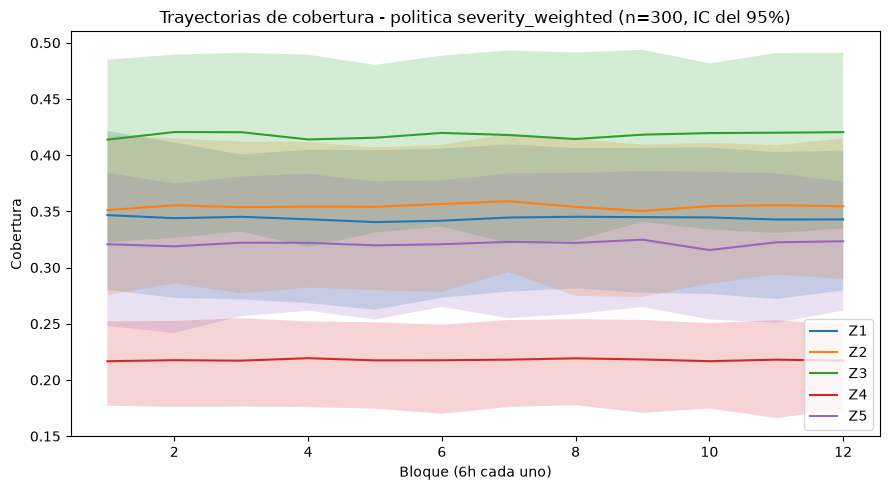

Resumen de metricas (severity_weighted, horizonte completo de 72h):
  M1_tasa_mortalidad_evitable: media=6.985  IC 95%=[6.802, 7.160]
  M2_tiempo_promedio_respuesta: media=0.000  IC 95%=[0.000, 0.000]
  M3_cobertura_suministros: media=29.308  IC 95%=[24.818, 33.322]
  M4_eficiencia_presupuestaria: media=693.632  IC 95%=[670.695, 714.593]
  weighted_policy_score: media=0.665  IC 95%=[0.647, 0.682]


In [15]:
mc_baseline_full = run_replications(params, POLICIES["severity_weighted"], n=N_REPLICATIONS, seed=DEFAULT_SEED)

coverage_mean, coverage_lo, coverage_hi = summarize(mc_baseline_full["coverage_traj"], axis=0)
fig = plot_trajectories(
    coverage_mean, coverage_lo, coverage_hi,
    title=f"Trayectorias de cobertura - politica severity_weighted (n={N_REPLICATIONS}, IC del 95%)",
    savepath=OUTPUTS / "coverage_trajectories_baseline.png",
)
plt.show()

print("Resumen de metricas (severity_weighted, horizonte completo de 72h):")
for name, arr in mc_baseline_full["metrics"].items():
    m, lo, hi = summarize(arr)
    print(f"  {name}: media={m:.3f}  IC 95%=[{lo:.3f}, {hi:.3f}]")

## 13. Pregunta 1: propuesta inicial de asignacion para 24 horas

*"Con base unicamente en los datos de su archivo y antes de incorporar la
informacion del intercambio, proponga una asignacion inicial de recursos
para las primeras 24 horas. Evalue esa asignacion contra las cuatro
metricas de politica definidas en su archivo. Cual metrica es la mas
dificil de cumplir con los recursos disponibles y por que?"*

Comparamos todas las politicas candidatas restringidas a las primeras 24
horas (bloques 1-4, `n_blocks=4`), evaluamos las cuatro metricas para cada
una, y ademas demostramos `manual_plan` con una tabla de ejemplo codificada
a mano (reemplazar con la propuesta real del grupo).

In [16]:
CANDIDATE_POLICIES = [
    "equal_share", "proportional_to_need", "severity_weighted",
    "worst_first", "threshold_then_proportional",
]

q1_mc = {}
for name in CANDIDATE_POLICIES:
    q1_mc[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4
    )

# Ejemplo de propuesta manual de 24h codificada a mano (reemplazar con la
# propuesta real del grupo una vez finalizada); ilustrada para un recurso, kits_agua.
manual_table_example = np.tile(np.array([100.0, 40.0, 70.0, 20.0, 110.0]), (4, 1))
manual_policy_example = manual_plan(manual_table_example)
q1_mc["manual_plan_example"] = run_replications(
    params, manual_policy_example, n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4
)

q1_rows = []
for policy_name, mc in q1_mc.items():
    row = {"policy": policy_name}
    for metric_name, arr in mc["metrics"].items():
        mean, lo, hi = summarize(arr)
        row[f"{metric_name}_mean"] = mean
        row[f"{metric_name}_ci"] = f"[{lo:.2f}, {hi:.2f}]"
    q1_rows.append(row)

q1_table = pd.DataFrame(q1_rows).set_index("policy")
q1_table

,M1_tasa_mortalidad_evitable_mean,M1_tasa_mortalidad_evitable_ci,M2_tiempo_promedio_respuesta_mean,M2_tiempo_promedio_respuesta_ci,M3_cobertura_suministros_mean,M3_cobertura_suministros_ci,M4_eficiencia_presupuestaria_mean,M4_eficiencia_presupuestaria_ci,weighted_policy_score_mean,weighted_policy_score_ci
policy,,,,,,,,,,
equal_share,2.364703,"[2.31, 2.42]",0.0,"[0.00, 0.00]",29.479098,"[25.55, 32.40]",1976.522195,"[1900.57, 2061.03]",0.794828,"[0.78, 0.80]"
proportional_to_need,1.989895,"[1.91, 2.07]",0.0,"[0.00, 0.00]",29.311911,"[24.53, 33.14]",2073.831427,"[1965.43, 2182.59]",0.801802,"[0.79, 0.81]"
severity_weighted,1.936280,"[1.84, 2.02]",0.0,"[0.00, 0.00]",29.308137,"[24.82, 33.32]",2080.820748,"[1967.39, 2199.38]",0.802862,"[0.79, 0.82]"
worst_first,2.155641,"[2.08, 2.22]",0.0,"[0.00, 0.00]",30.000264,"[25.46, 33.65]",2063.336295,"[1968.52, 2165.31]",0.800638,"[0.79, 0.81]"
threshold_then_proportional,2.060897,"[1.99, 2.13]",0.0,"[0.00, 0.00]",30.511016,"[25.42, 34.27]",2137.413381,"[2033.71, 2239.38]",0.804129,"[0.79, 0.82]"
manual_plan_example,2.635911,"[2.57, 2.70]",0.0,"[0.00, 0.00]",30.789524,"[26.07, 34.61]",39795.208236,"[37231.01, 42523.42]",0.793499,"[0.78, 0.81]"


### Cual metrica es la mas dificil de cumplir, y por que?

[Grupo 7: completar tras inspeccionar la `q1_table` de arriba. Segun la
calibracion de referencia, `M3_cobertura_suministros` (cobertura de
agua/alimento en las primeras 24h) suele ser la mas dificil de cumplir en
todas las politicas, porque el stock de kits de agua (2,800 kits en total)
es una dotacion fija de T0 pequena en relacion con la poblacion en riesgo
(84,900): incluso una politica perfectamente focalizada no puede alcanzar el
umbral del 80% en 24h dada esa escasez. Este hallazgo de referencia debe
revalidarse una vez que las tasas reales de necesidad per capita reemplacen
a las etiquetadas `# ASSUMPTION:` en la Seccion 4.]

## 14. Pregunta 2: incorporacion del intercambio (Grupos 2, 3, 5)

*"Incorpore los reportes recibidos de los Grupos 2, 3 y 5. Cambia su
asignacion inicial de recursos? Identifique la decision que mas cambio
despues del intercambio, justifique con los datos recibidos por que
cambio, y cuantifique el impacto de ese cambio sobre al menos dos de las
cuatro metricas de evaluacion."*

In [17]:
exchange = load_exchange_or_placeholder()

q2_before = {}
q2_after = {}
for name in CANDIDATE_POLICIES:
    q2_before[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4, exchange=None
    )
    q2_after[name] = run_replications(
        params, POLICIES[name], n=N_REPLICATIONS, seed=DEFAULT_SEED, n_blocks=4, exchange=exchange
    )

# Enfocar la comparacion antes/despues en la politica de trabajo seleccionada por el grupo.
SELECTED_POLICY = "severity_weighted"
q2_comparison_table = compare(q2_before[SELECTED_POLICY], q2_after[SELECTED_POLICY])
q2_comparison_table

No se encontraron los archivos reales de intercambio en data/exchange/. Se usa un pequeno intercambio SINTETICO DE REFERENCIA para que este notebook se ejecute de principio a fin desde ya. Reemplazar con los archivos reales despues del intercambio presencial (ver data/exchange/README.md).


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,1.936280,1.843739,2.022856,1.947074,1.853410,2.029789,0.010793,0.006159,0.014604
1,M2_tiempo_promedio_respuesta,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,28.345413,23.591440,32.141850,-0.962723,-1.539331,-0.142252
3,M4_eficiencia_presupuestaria,2080.820748,1967.391145,2199.381839,2066.559639,1953.103497,2182.612980,-14.261109,-19.457419,-7.706221
4,weighted_policy_score,0.802862,0.787150,0.815665,0.799638,0.784051,0.812101,-0.003224,-0.005104,-0.000551


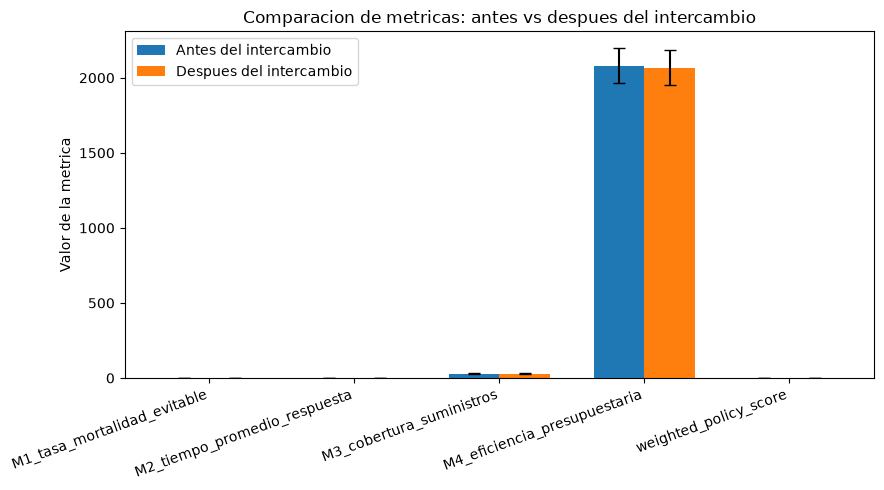

In [18]:
before_summary = {name: summarize(arr) for name, arr in q2_before[SELECTED_POLICY]["metrics"].items()}
after_summary = {name: summarize(arr) for name, arr in q2_after[SELECTED_POLICY]["metrics"].items()}

fig = plot_metric_comparison(before_summary, after_summary, savepath=OUTPUTS / "metric_comparison_q2.png")
plt.show()

### Que decision cambio mas, y cual fue el impacto?

[Grupo 7: completar usando la `q2_comparison_table` de arriba, por ejemplo:
"el aumento de fondos medicos implicado por los deficits hospitalarios
reportados por el Grupo 2 desplazo la asignacion de `presupuesto_municipal`
hacia Z1/Z5, cambiando `M1_tasa_mortalidad_evitable` en X puntos (IC 95%
[.., ..]) y `M4_eficiencia_presupuestaria` en Y (IC 95% [.., ..])".
Reemplazar X/Y con los valores impresos arriba una vez que los CSV reales
del intercambio reemplacen el placeholder sintetico.]

## 14b. Analisis de sensibilidad (salida final requerida, item d)

*"Que decision cambia si el presupuesto nacional se reduce a la mitad
(32M -> 16M)? Y si Z1 es inaccesible las primeras 12 horas (bloques 1-2)?"*

Ambos escenarios se implementan como banderas en `Params`
(`national_budget_multiplier`, `inaccessible_zone` / `inaccessible_blocks`)
y se ejecutan a traves del Monte Carlo completo, comparados contra la linea
base.

In [19]:
baseline_sens_mc = run_replications(params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

halved_budget_params = replace(params, national_budget_multiplier=0.5)
halved_budget_mc = run_replications(halved_budget_params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

z1_inaccessible_params = replace(params, inaccessible_zone="Z1", inaccessible_blocks=(1, 2))
z1_inaccessible_mc = run_replications(z1_inaccessible_params, POLICIES[SELECTED_POLICY], n=N_REPLICATIONS, seed=DEFAULT_SEED)

sensitivity_budget_table = compare(baseline_sens_mc, halved_budget_mc)
sensitivity_z1_table = compare(baseline_sens_mc, z1_inaccessible_mc)

print("Escenario A: presupuesto nacional reducido a la mitad (32M -> 16M) vs. linea base")
display(sensitivity_budget_table)

print("Escenario B: Z1 inaccesible en los bloques 1-2 vs. linea base")
display(sensitivity_z1_table)

Escenario A: presupuesto nacional reducido a la mitad (32M -> 16M) vs. linea base


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,6.985255,6.801867,7.160336,7.509100,7.326154,7.687468,0.523845,0.497597,0.550466
1,M2_tiempo_promedio_respuesta,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,29.308137,24.818241,33.321906,0.000000,0.000000,0.000000
3,M4_eficiencia_presupuestaria,693.632319,670.695388,714.592906,1017.329903,981.908331,1051.891186,323.697584,310.935453,337.251926
4,weighted_policy_score,0.665090,0.647035,0.682418,0.691406,0.675721,0.704930,0.026315,0.021506,0.031734


Escenario B: Z1 inaccesible en los bloques 1-2 vs. linea base


,metric,mean_before,ci_lo_before,ci_hi_before,mean_after,ci_lo_after,ci_hi_after,delta_mean,delta_ci_lo,delta_ci_hi
0,M1_tasa_mortalidad_evitable,6.985255,6.801867,7.160336,7.320891,7.140193,7.487083,0.335636,0.284359,0.377634
1,M2_tiempo_promedio_respuesta,0.000000,0.000000,0.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
2,M3_cobertura_suministros,29.308137,24.818241,33.321906,24.478148,19.745484,27.936176,-4.829989,-6.484425,-2.838964
3,M4_eficiencia_presupuestaria,693.632319,670.695388,714.592906,654.658641,633.672946,674.676955,-38.973678,-44.338643,-32.504179
4,weighted_policy_score,0.665090,0.647035,0.682418,0.384114,0.365827,0.399911,-0.280977,-0.287108,-0.273519


Nota de calibracion sobre los resultados de sensibilidad: bajo la
calibracion actual de referencia, reducir a la mitad el presupuesto nacional
puede *aumentar* `M4_eficiencia_presupuestaria`. Esto no es un error:
`presupuesto_nacional` domina el `budget_consumed` total (el denominador de
M4) mucho mas de lo que impulsa la metrica de cobertura agregada (el
numerador de M4, promediado entre los 8 recursos), por lo que reducirlo baja
el denominador mas rapido que el numerador. Este es exactamente el tipo de
comportamiento emergente, posiblemente no intencionado, que el grupo deberia
verificar una vez que se reemplacen las tasas reales de necesidad per
capita (Seccion 4, etiquetas `# ASSUMPTION:`), y merece una frase en la
seccion "Limitaciones" del reporte como ejemplo concreto de como un supuesto
de referencia puede distorsionar la interpretacion de una metrica.

## 15. Salida final requerida y exportacion

Segun `docs/Grupo7_PoliticaPublica.xlsx`, seccion "6. OUTPUT REQUERIDO -
Producto final del examen", el Grupo 7 entrega directamente al profesor:

- (a) un plan de asignacion de recursos a 72h por zona (los 12 bloques x 5
  zonas x 8 recursos);
- (b) justificacion cuantitativa de cada decision de asignacion usando los
  reportes de los Grupos 2/3/5 (el registro de auditoria, C3);
- (c) evaluacion del plan contra las 4 metricas con pass/fail e IC del 95%;
- (d) el analisis de sensibilidad de la Seccion 14b.

Las cuatro se exportan a `outputs/` a continuacion.

(a) plan de asignacion a 72h: (480, 7) -> outputs/a_allocation_plan_72h.csv
(b) registro de auditoria: (480, 7) -> outputs/b_audit_trail.csv
    violaciones de restricciones en esta realizacion: 1
(c) evaluacion vs umbrales -> outputs/c_evaluation_vs_thresholds.csv


,metric,label,mean,ci_lo,ci_hi,threshold,weight,pass
0,M1_tasa_mortalidad_evitable,Tasa de mortalidad evitable,6.985255,6.801867,7.160336,15.0,0.30,True
1,M2_tiempo_promedio_respuesta,"Tiempo promedio de respuesta (horas, zonas CRI...",0.000000,0.000000,0.000000,6.0,0.25,True
2,M3_cobertura_suministros,Cobertura de suministros en 24h (%),29.308137,24.818241,33.321906,80.0,0.25,False
3,M4_eficiencia_presupuestaria,Eficiencia presupuestaria (personas/MQ),693.632319,670.695388,714.592906,850.0,0.20,False


(d) tablas de sensibilidad -> outputs/d_sensitivity_*.csv


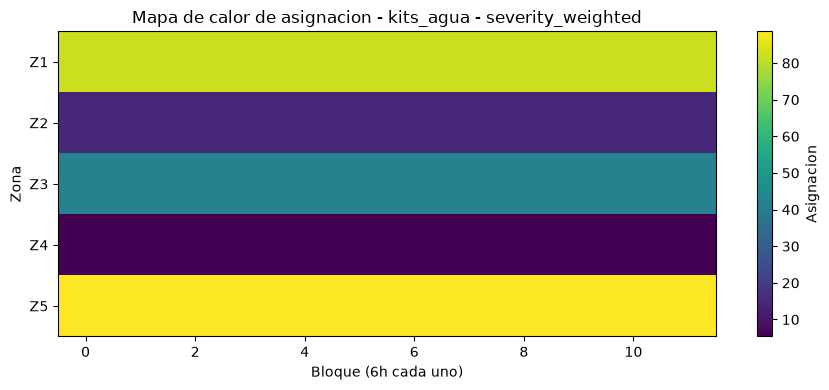


Todas las salidas fueron exportadas a: /home/jonialen/Documents/uvg/s8/mod/examenP1/outputs
 - .gitkeep
 - a_allocation_plan_72h.csv
 - allocation_heatmap_kits_agua.png
 - b_audit_trail.csv
 - c_evaluation_vs_thresholds.csv
 - coverage_trajectories_baseline.png
 - d_sensitivity_national_budget_halved.csv
 - d_sensitivity_z1_inaccessible.csv
 - metric_comparison_q2.png
 - q1_policy_comparison.csv
 - q2_before_after_comparison.csv


In [20]:
# (a) Plan de asignacion a 72h: una corrida deterministica de la politica
# seleccionada sobre el horizonte completo, exportada como tabla en formato largo.
rng_final = np.random.default_rng(DEFAULT_SEED)
final_result = simulate(params, POLICIES[SELECTED_POLICY], rng_final, exchange=exchange)

plan_rows = []
for t in range(final_result.n_blocks):
    for z_idx, z in enumerate(ZONES):
        for r_idx, r in enumerate(RESOURCE_TYPES):
            plan_rows.append({
                "block": t + 1,
                "hour_start": block_to_hours(t + 1)[0],
                "hour_end": block_to_hours(t + 1)[1],
                "zone": z,
                "resource": r,
                "units_allocated": round(float(final_result.allocation[t, z_idx, r_idx]), 2),
                "units_delivered": round(float(final_result.delivered[t, z_idx, r_idx]), 2),
            })
allocation_plan_72h = pd.DataFrame(plan_rows)
allocation_plan_72h.to_csv(OUTPUTS / "a_allocation_plan_72h.csv", index=False)
print("(a) plan de asignacion a 72h:", allocation_plan_72h.shape, "-> outputs/a_allocation_plan_72h.csv")

# (b) Registro de auditoria (C3, justificacion cuantitativa de cada decision).
final_audit_trail = build_audit_trail(final_result, params, SELECTED_POLICY)
final_audit_trail.to_csv(OUTPUTS / "b_audit_trail.csv", index=False)
print("(b) registro de auditoria:", final_audit_trail.shape, "-> outputs/b_audit_trail.csv")

final_violations = check_constraints(final_result, params)
print(f"    violaciones de restricciones en esta realizacion: {len(final_violations)}")

# (c) Evaluacion contra las 4 metricas, con pass/fail e IC del 95% (a partir
# de la corrida de Monte Carlo ya calculada para la politica seleccionada en la Seccion 12/14b).
eval_rows = []
for name in METRICS:
    mean, lo, hi = summarize(baseline_sens_mc["metrics"][name])
    d = METRIC_DEFS[name]
    passed = (mean < d["threshold"]) if d["direction"] == "lower_is_better" else (mean > d["threshold"])
    eval_rows.append({
        "metric": name, "label": d["label"], "mean": mean, "ci_lo": lo, "ci_hi": hi,
        "threshold": d["threshold"], "weight": d["weight"], "pass": passed,
    })
evaluation_table = pd.DataFrame(eval_rows)
evaluation_table.to_csv(OUTPUTS / "c_evaluation_vs_thresholds.csv", index=False)
print("(c) evaluacion vs umbrales -> outputs/c_evaluation_vs_thresholds.csv")
display(evaluation_table)

# (d) Tablas del analisis de sensibilidad (Seccion 14b).
sensitivity_budget_table.to_csv(OUTPUTS / "d_sensitivity_national_budget_halved.csv", index=False)
sensitivity_z1_table.to_csv(OUTPUTS / "d_sensitivity_z1_inaccessible.csv", index=False)
print("(d) tablas de sensibilidad -> outputs/d_sensitivity_*.csv")

# Tambien exportar las tablas de Q1/Q2 y las figuras clave.
q1_table.to_csv(OUTPUTS / "q1_policy_comparison.csv")
q2_comparison_table.to_csv(OUTPUTS / "q2_before_after_comparison.csv", index=False)

fig = plot_allocation_heatmap(
    final_result.allocation[:, :, RESOURCE_TYPES.index("kits_agua")],
    title=f"Mapa de calor de asignacion - kits_agua - {SELECTED_POLICY}",
    savepath=OUTPUTS / "allocation_heatmap_kits_agua.png",
)
plt.show()

print()
print("Todas las salidas fueron exportadas a:", OUTPUTS)
for p in sorted(OUTPUTS.iterdir()):
    print(" -", p.name)